In [45]:

    # classification
    
    
    
    

In [17]:
### Import libraries and read the data - Data Access 
file = "C:\\Users\\ADMIN\\Desktop\\AI_ML\\DAY03\\predictive_maintenance.csv"
import pandas as pd
import seaborn as sns
df = pd.read_csv (file)
df.columns

Index(['Unnamed: 0', 'MachineID', 'OperatingTemperature', 'VibrationLevel',
       'CycleCount', 'AmbientTemperature', 'OperatingHours',
       'FailureProbability', 'FailureStatus'],
      dtype='object')

In [19]:
#Data quality chec - Explore
#Eyeball the data
#There is unlabed columns - unamed, that will drop from the data frame
vars = df.columns.drop('Unnamed: 0')
df1 = df[vars]
df1.describe()


,OperatingTemperature,VibrationLevel,CycleCount,AmbientTemperature,OperatingHours,FailureProbability,FailureStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,70.752048,0.500932,5348.979000,24.840850,11.86000,0.414195,0.10000
std,20.027956,0.111116,2626.944147,5.504840,6.67075,0.160552,0.30015
min,11.001714,0.157164,32.000000,5.670481,1.00000,0.000000,0.00000
25%,57.473343,0.424891,3160.500000,21.322154,6.00000,0.310466,0.00000
50%,70.735089,0.502749,5147.500000,24.714173,12.00000,0.403734,0.00000
75%,83.576713,0.576787,7536.000000,28.519141,18.00000,0.516254,0.00000
max,132.656150,0.848540,10921.000000,42.628367,23.00000,1.000000,1.00000


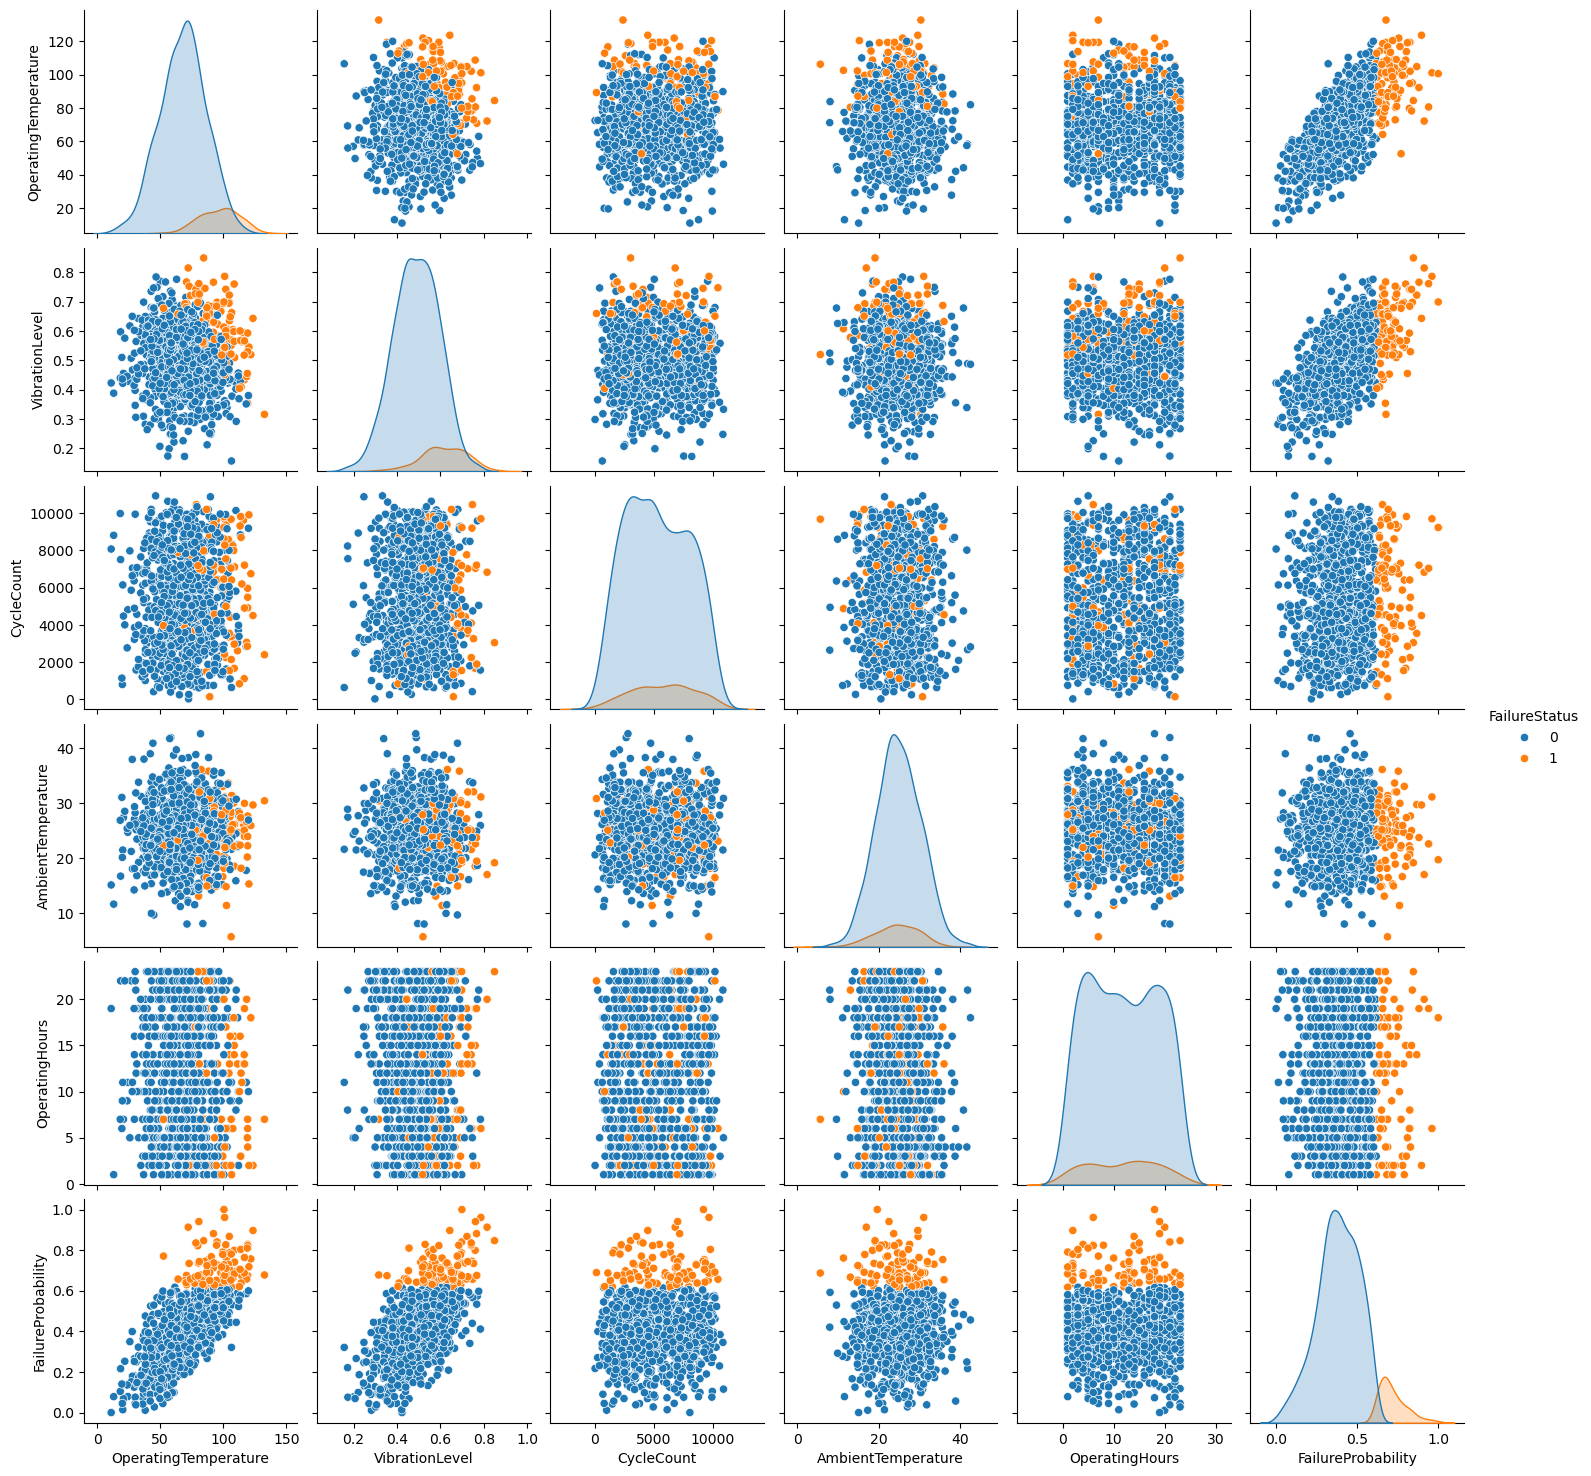

In [41]:
import seaborn as sns
sns.pairplot(df1, hue = ("FailureStatus"))

In [43]:
#From the above plot,we can identify failures happening after long operationl hours, vibratino level  and failure probability

In [21]:
#create definition to build the model
def build_model (model, X, y, tsz):
    import pandas as pd
    import seaborn as sns
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import classification_report

    X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = tsz)
    mod = model()
    mod.fit(X_train, y_train)
    pred = mod.predict(X_train)
    #print ("Training data prediction:", pred)
    print ("Training data Performance :\n")
    compute_metrics(y_train, pred)
    pred = mod.predict(X_test)
    #print ("Testing data prediction:", pred)
    print ("Testing data Performance :\n")
    compute_metrics(y_test, pred)

In [23]:
#Now i will create a dataframe with only required 3 variables as X and 1 variable as y
vars = ['OperatingTemperature', 'VibrationLevel','FailureProbability']
X = df1[vars]
y = df1['FailureStatus']
print ("Xshape :", X.shape)
print ("yshape :", y.shape)

Xshape : (1000, 3)
yshape : (1000,)


In [75]:
#Now run the above function by passing reference
from sklearn.linear_model import LogisticRegression
build_model (LogisticRegression, X, y, 0.3)

In [25]:
#Now we build the function for performance
def compute_metrics(y, pred):
    from sklearn.metrics import classification_report
    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import accuracy_score
    print ("Accuracy :\n", accuracy_score(y, pred))
    print ("Confusion matrix :\n", confusion_matrix(y, pred))
    print ("Classification Report :\n", classification_report(y, pred))

In [93]:
#Now we call this performance function inside the build_model function
#from sklearn.linear_model import LogisticRegression
build_model(LogisticRegression, X, y, 0.3)

Training data Performance :

Accuracy :
 0.96
Confusion matrix :
 [[626   3]
 [ 25  46]]
Classification Report :
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       629
           1       0.94      0.65      0.77        71

    accuracy                           0.96       700
   macro avg       0.95      0.82      0.87       700
weighted avg       0.96      0.96      0.96       700

Testing data Performance :

Accuracy :
 0.9533333333333334
Confusion matrix :
 [[270   1]
 [ 13  16]]
Classification Report :
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       271
           1       0.94      0.55      0.70        29

    accuracy                           0.95       300
   macro avg       0.95      0.77      0.84       300
weighted avg       0.95      0.95      0.95       300



In [101]:
#Naive bayesian classifier
from sklearn.naive_bayes import GaussianNB
build_model(GaussianNB, X, y, 0.3)

Training data Performance :

Accuracy :
 0.9857142857142858
Confusion matrix :
 [[625   7]
 [  3  65]]
Classification Report :
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       632
           1       0.90      0.96      0.93        68

    accuracy                           0.99       700
   macro avg       0.95      0.97      0.96       700
weighted avg       0.99      0.99      0.99       700

Testing data Performance :

Accuracy :
 0.9833333333333333
Confusion matrix :
 [[267   1]
 [  4  28]]
Classification Report :
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       268
           1       0.97      0.88      0.92        32

    accuracy                           0.98       300
   macro avg       0.98      0.94      0.95       300
weighted avg       0.98      0.98      0.98       300



In [103]:
#Decision trees
from sklearn import tree
clf = tree.DecisionTreeClassifier()
clf.fit(X, y)

DecisionTreeClassifier()

[Text(0.5, 0.75, 'x[2] <= 0.617\ngini = 0.18\nsamples = 1000\nvalue = [900, 100]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 900\nvalue = [900, 0]'),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 100\nvalue = [0, 100]')]

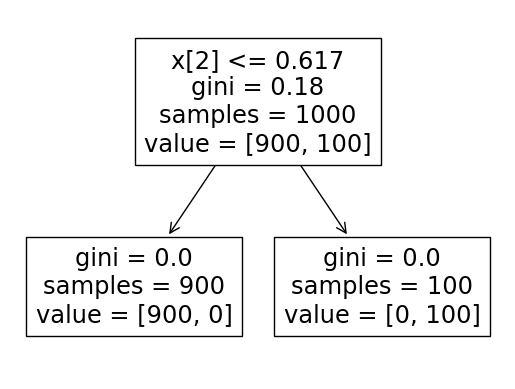

In [105]:
tree.plot_tree(clf)

In [109]:
#Build the decision tree and get performance
build_model(tree.DecisionTreeClassifier, X,y,0.3)

Training data Performance :

Accuracy :
 1.0
Confusion matrix :
 [[637   0]
 [  0  63]]
Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       637
           1       1.00      1.00      1.00        63

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

Testing data Performance :

Accuracy :
 0.9933333333333333
Confusion matrix :
 [[263   0]
 [  2  35]]
Classification Report :
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       263
           1       1.00      0.95      0.97        37

    accuracy                           0.99       300
   macro avg       1.00      0.97      0.98       300
weighted avg       0.99      0.99      0.99       300



In [111]:
#Support vector machine
from sklearn.svm import LinearSVC
build_model(LinearSVC, X,y,0.3)

C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training data Performance :

Accuracy :
 0.8971428571428571
Confusion matrix :
 [[628   0]
 [ 72   0]]
Classification Report :
               precision    recall  f1-score   support

           0       0.90      1.00      0.95       628
           1       0.00      0.00      0.00        72

    accuracy                           0.90       700
   macro avg       0.45      0.50      0.47       700
weighted avg       0.80      0.90      0.85       700

Testing data Performance :

Accuracy :
 0.9066666666666666
Confusion matrix :
 [[272   0]
 [ 28   0]]
Classification Report :
               precision    recall  f1-score   support

           0       0.91      1.00      0.95       272
           1       0.00      0.00      0.00        28

    accuracy                           0.91       300
   macro avg       0.45      0.50      0.48       300
weighted avg       0.82      0.91      0.86       300



C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\anaconda3\Lib\site-packag

In [113]:
#Neural networks
from sklearn.neural_network import MLPClassifier
build_model(MLPClassifier, X, y, 0.1)

Training data Performance :

Accuracy :
 0.94
Confusion matrix :
 [[811   0]
 [ 54  35]]
Classification Report :
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       811
           1       1.00      0.39      0.56        89

    accuracy                           0.94       900
   macro avg       0.97      0.70      0.77       900
weighted avg       0.94      0.94      0.93       900

Testing data Performance :

Accuracy :
 0.96
Confusion matrix :
 [[89  0]
 [ 4  7]]
Classification Report :
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        89
           1       1.00      0.64      0.78        11

    accuracy                           0.96       100
   macro avg       0.98      0.82      0.88       100
weighted avg       0.96      0.96      0.96       100



C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [115]:
#KNN classifier
from sklearn.neighbors import KNeighborsClassifier
build_model(KNeighborsClassifier, X, y, 0.3)

Training data Performance :

Accuracy :
 0.9371428571428572
Confusion matrix :
 [[620  11]
 [ 33  36]]
Classification Report :
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       631
           1       0.77      0.52      0.62        69

    accuracy                           0.94       700
   macro avg       0.86      0.75      0.79       700
weighted avg       0.93      0.94      0.93       700

Testing data Performance :

Accuracy :
 0.9
Confusion matrix :
 [[257  12]
 [ 18  13]]
Classification Report :
               precision    recall  f1-score   support

           0       0.93      0.96      0.94       269
           1       0.52      0.42      0.46        31

    accuracy                           0.90       300
   macro avg       0.73      0.69      0.70       300
weighted avg       0.89      0.90      0.90       300



In [117]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
build_model(RandomForestClassifier, X, y, 0.3)

Training data Performance :

Accuracy :
 1.0
Confusion matrix :
 [[626   0]
 [  0  74]]
Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       626
           1       1.00      1.00      1.00        74

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

Testing data Performance :

Accuracy :
 1.0
Confusion matrix :
 [[274   0]
 [  0  26]]
Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       274
           1       1.00      1.00      1.00        26

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [119]:
#GBM classifier
from sklearn.ensemble import GradientBoostingClassifier
build_model(GradientBoostingClassifier, X, y, 0.3)

Training data Performance :

Accuracy :
 1.0
Confusion matrix :
 [[628   0]
 [  0  72]]
Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       628
           1       1.00      1.00      1.00        72

    accuracy                           1.00       700
   macro avg       1.00      1.00      1.00       700
weighted avg       1.00      1.00      1.00       700

Testing data Performance :

Accuracy :
 1.0
Confusion matrix :
 [[272   0]
 [  0  28]]
Classification Report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       272
           1       1.00      1.00      1.00        28

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [121]:
X


,OperatingTemperature,VibrationLevel,FailureProbability
0,77.732663,0.689170,0.610724
1,108.653637,0.759652,0.799017
2,88.334134,0.567402,0.529597
3,57.718041,0.247715,0.245982
4,51.379493,0.568552,0.340816
...,...,...,...
995,60.967288,0.416625,0.238663
996,113.309596,0.600133,0.705552
997,58.631149,0.559364,0.329458
998,84.880406,0.510468,0.480709


In [123]:
X[vars]

,OperatingTemperature,VibrationLevel,FailureProbability
0,77.732663,0.689170,0.610724
1,108.653637,0.759652,0.799017
2,88.334134,0.567402,0.529597
3,57.718041,0.247715,0.245982
4,51.379493,0.568552,0.340816
...,...,...,...
995,60.967288,0.416625,0.238663
996,113.309596,0.600133,0.705552
997,58.631149,0.559364,0.329458
998,84.880406,0.510468,0.480709


In [125]:
df1

,MachineID,OperatingTemperature,VibrationLevel,CycleCount,AmbientTemperature,OperatingHours,FailureProbability,FailureStatus
0,M3,77.732663,0.689170,7238,30.230308,13,0.610724,0
1,M4,108.653637,0.759652,1671,18.511730,15,0.799017,1
2,M1,88.334134,0.567402,8603,38.287785,4,0.529597,0
3,M3,57.718041,0.247715,3075,32.758765,16,0.245982,0
4,M3,51.379493,0.568552,4016,23.599941,12,0.340816,0
...,...,...,...,...,...,...,...,...
995,M1,60.967288,0.416625,9032,14.778434,13,0.238663,0
996,M1,113.309596,0.600133,9309,22.353050,16,0.705552,1
997,M4,58.631149,0.559364,8021,32.475441,16,0.329458,0
998,M4,84.880406,0.510468,2584,30.328127,3,0.480709,0


In [130]:
df2 =df1.drop('MachineID', axis =1)

In [132]:
df2


,OperatingTemperature,VibrationLevel,CycleCount,AmbientTemperature,OperatingHours,FailureProbability,FailureStatus
0,77.732663,0.689170,7238,30.230308,13,0.610724,0
1,108.653637,0.759652,1671,18.511730,15,0.799017,1
2,88.334134,0.567402,8603,38.287785,4,0.529597,0
3,57.718041,0.247715,3075,32.758765,16,0.245982,0
4,51.379493,0.568552,4016,23.599941,12,0.340816,0
...,...,...,...,...,...,...,...
995,60.967288,0.416625,9032,14.778434,13,0.238663,0
996,113.309596,0.600133,9309,22.353050,16,0.705552,1
997,58.631149,0.559364,8021,32.475441,16,0.329458,0
998,84.880406,0.510468,2584,30.328127,3,0.480709,0


In [134]:
df2.max()

OperatingTemperature      132.656150
VibrationLevel              0.848540
CycleCount              10921.000000
AmbientTemperature         42.628367
OperatingHours             23.000000
FailureProbability          1.000000
FailureStatus               1.000000
dtype: float64

In [136]:
df2 = df2/df2.max()

In [138]:
df2.sample(10)

,OperatingTemperature,VibrationLevel,CycleCount,AmbientTemperature,OperatingHours,FailureProbability,FailureStatus
107,0.395495,0.632452,0.137991,0.812670,0.043478,0.305030,0.0
386,0.626261,0.652633,0.686933,0.480950,0.739130,0.400193,0.0
917,0.420886,0.533145,0.780331,0.605056,0.695652,0.343821,0.0
541,0.581579,0.602093,0.298324,0.481224,0.913043,0.394504,0.0
260,0.137252,0.517726,0.913195,0.630579,0.304348,0.104251,0.0
732,0.553257,0.344201,0.682721,0.572896,0.826087,0.200813,0.0
222,0.268623,0.750568,0.111254,0.531447,0.826087,0.208833,0.0
895,0.507236,0.522413,0.276715,0.894363,0.695652,0.310617,0.0
61,0.388859,0.516632,0.768336,0.721631,0.826087,0.371936,0.0
730,0.893474,0.523900,0.280744,0.624563,0.869565,0.657665,1.0


In [140]:
df2[df2.FailureProbability >= 0.617]

,OperatingTemperature,VibrationLevel,CycleCount,AmbientTemperature,OperatingHours,FailureProbability,FailureStatus
1,0.819062,0.895247,0.153008,0.434258,0.652174,0.799017,1.0
7,0.794399,0.612570,0.640692,0.645954,0.956522,0.636658,1.0
24,0.638662,0.762592,0.472026,0.385416,1.000000,0.640016,1.0
27,0.716125,0.822203,0.356835,0.449380,0.913043,0.840280,1.0
32,0.719598,0.734562,0.363611,0.545825,0.565217,0.726710,1.0
...,...,...,...,...,...,...,...
925,0.656149,0.800342,0.371669,0.349963,0.086957,0.723982,1.0
937,0.602168,0.821996,0.657541,0.459341,1.000000,0.673568,1.0
988,0.744166,0.610509,0.639410,0.654232,0.043478,0.717183,1.0
993,0.799607,0.614390,0.644996,0.589926,0.086957,0.652531,1.0


In [113]:
#create definition to build the model
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
model_map = {
    'LogisticRegression': LogisticRegression,
    'tree.DecisionTreeClassifier': tree.DecisionTreeClassifier,
    'GaussianNB' : GaussianNB ,
    'LinearSVC': LinearSVC,
    'MLPClassifier' : MLPClassifier,
    'KNeighborsClassifier' : KNeighborsClassifier,
    'RandomForestClassifier' : RandomForestClassifier,
    'GradientBoostingClassifier' : GradientBoostingClassifier
   }

def build_model (model_name, X, y, tsz):
    import pandas as pd
    import seaborn as sns
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import classification_report
    
    model_class = model_map.get(model_name)
    model = model_class()
    
    X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = tsz)
    #mod = model()
    model.fit(X_train, y_train)
    pred = model.predict(X_train)
    #print ("Training data prediction:", pred)
    print ("Training data Performance :\n")
    compute_metrics(y_train, pred)
    pred = model.predict(X_test)
    #print ("Testing data prediction:", pred)
    print ("Testing data Performance :\n")
    compute_metrics(y_test, pred)
    
    

In [211]:
#Now we build the function for performance
from tabulate import tabulate
from prettytable import PrettyTable 
def compute_metrics(y, pred):
    from sklearn.metrics import classification_report
    from sklearn.metrics import confusion_matrix
    from sklearn.metrics import accuracy_score
    #print ("Accuracy :\n", accuracy_score(y, pred))
    #print ("Confusion matrix :\n", confusion_matrix(y, pred))
    #print ("Classification Report :\n", classification_report(y, pred))
    #head = ["confusion_matrix", "accuracy_score"]
    #table = [[confusion_matrix(y, pred)] , [accuracy_score(y,pred)] ]
    mytable = PrettyTable(["confusion_matrix", "accuracy_score"])
    mytable.addrow([confusion_matrix(y, pred), accuracy_score(y,pred)])
    print(tabulate(table, headers=head, tablefmt='grid'))
    
    #print (confusion_matrix(y, pred), "\t", accuracy_score(y,pred))
    #print (confusion_matrix(y, pred))

In [213]:
lst = ['LogisticRegression','tree.DecisionTreeClassifier', 'GaussianNB', 'LinearSVC', 'MLPClassifier', 'KNeighborsClassifier','RandomForestClassifier','GradientBoostingClassifier']


#file = open('linreg01_perf.csv', 'w')
#file.write (" Accuracy           - Confusion Matrix -  ")
#file.close()
per = [0.1,0.2,0.3]
for i in per:
    for key in range(len(lst)):
        print("######################", lst[key], " with ", i , "###################", "\n")
        #print ("\n Accuracy           - Confusion Matrix -  ")
             
        build_model(lst[key], X, y, i)

###################### LogisticRegression  with  0.1 ################### 

Training data Performance :



AttributeError: addrow

In [205]:
pip install prettytable 

Note: you may need to restart the kernel to use updated packages.
